In [22]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [8]:
class BatsmanState(TypedDict):

    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    boundary_percent:float
    summary:str

In [18]:
# If we return whole state it will think that eachnode is giving some different vlues of the state variables which are not changed
# (Ex runs , balls) we are just using them so it will conflict on ther values so instead of returning whole state 
# we return particular variable which is changed in dictionary as node function expects to have dictionary as input and output

def Calculate_sr(state:BatsmanState) -> BatsmanState:
    sr = (state['runs']/state['balls'])*100
    
    return {"sr" : sr}

def Calculate_bpb(state:BatsmanState) -> BatsmanState:

    bpb = state['balls']/(state['fours']+state['sixes'])

    return {"bpb" : bpb}

def Calculate_boundary_percent(state:BatsmanState) -> BatsmanState:

    boundary_percent = ((state['fours']*4) + (state['sixes']*6))/state['runs'] *100

    return {"boundary_percent" : boundary_percent}

def Summary(state:BatsmanState) -> BatsmanState:
    Summary = f"""
    Strike Rate - {state['sr']}\n
    Balls per Boundary - {state['bpb']} \n
    Boundary Percent - {state['boundary_percent']}
    """

    state['summary'] = Summary
    return state
    

In [19]:
graph=StateGraph(BatsmanState)

graph.add_node("Calculate_sr",Calculate_sr)
graph.add_node("Calculate_bpb",Calculate_bpb)
graph.add_node("Calculate_boundary_percent",Calculate_boundary_percent)
graph.add_node("Summary",Summary)

graph.add_edge(START,"Calculate_sr")
graph.add_edge(START,"Calculate_bpb")
graph.add_edge(START,"Calculate_boundary_percent")

graph.add_edge("Calculate_sr","Summary")
graph.add_edge("Calculate_bpb","Summary")
graph.add_edge("Calculate_boundary_percent","Summary")

graph.add_edge("Summary",END)

workflow = graph.compile()

In [20]:
initial_state = {
    "runs" : 100,
    "balls" : 50,
    "fours" : 6,
    "sixes" : 4    
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': '\n    Strike Rate - 200.0\n\n    Balls per Boundary - 5.0 \n\n    Boundary Percent - 48.0\n    '}


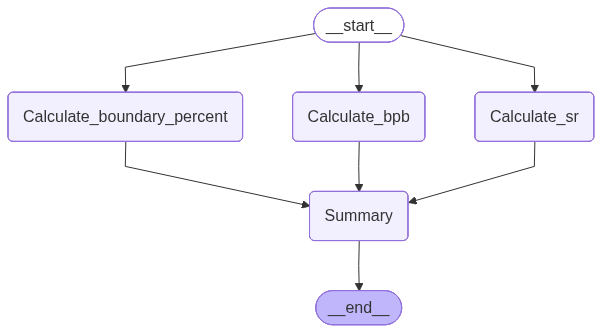

In [21]:
workflow